#### Plot each vgtye by specified colors
- Create a dictionary mapping each vgtype to a color
- Plotting with uxarray + Matplotlib
- using HoloViews with Bokeh for interactivity
- Add Custom Colorbar Labels

Ming Ge June 2025   For Ming Chen


In [1]:
import uxarray as ux
import holoviews as hv
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from bokeh.models import FixedTicker

In [2]:
flnm = "/glade/campaign/mmm/wmr/mchen/MPAS-Limited-Area/EuropeC.static.nc"
flnm = "/glade/campaign/mmm/c3we/juliak/MPAS_C404/global_uniform_15km/MPAS_C404_global_uniform_15km_init.nc"
ds_i = ux.open_dataset(flnm, flnm)
mesh = ds_i.uxgrid
ivgtyp = ds_i.ivgtyp

In [3]:
col_dict = {
    1: "tomato",
    2: "red",
    3: "plum",
    4: "green",
    5: "lightseagreen",
    6: "olivedrab",
    7: "lightgreen",
    8: "blue",
    9: "steelblue",
    10: "lightskyblue",
    11: "turquoise",
    12: "magenta",
    13: "hotpink",
    14: "lightpink",
    15: "violet",
    16: "ivory",
    17: "dodgerblue",  # fixed typo from "dodgeblue"
    18: "goldenrod",
    19: "brown",
    20: "darkorange",
}

labels = np.array([
    "Urban",
    "Cropland",
    "Grassland",
    "Grassland",
    "Grassland",
    "Grassland",
    "Grassland",
    "Grassland",
    "Grassland",
    "Grassland",
    "Grassland",
    "Grassland",
    "Grassland",
    "Grassland",
    "B Deciduous",
    "Mixed Forest",
    "Water Bodies",
    "H Wetland", 
    "Barren",
    "Tundra",
])

- using HoloViews with Bokeh for interactivity

In [4]:
# Build discrete color map
# 20 colors
colors = [col_dict[i] for i in sorted(col_dict.keys())]  
n_color = len(colors)

# 1 to 21 (21 edges, 20 intervals:edges vs. bins )
color_levels = list(range(n_color + 1))

# Map label ticks to color indices (centered)
major_label_overrides = {i + 0.5: labels[i-1] for i in range(1, n_color+1)}

hv_img = ivgtyp.plot()

hv_img.opts(
    cmap = colors, clim=(1, n_color+1), 
    color_levels=color_levels,
    colorbar=True,
    colorbar_opts={
        'title': 'Land Cover Type',
        'major_label_overrides': major_label_overrides,
        'ticker': FixedTicker(ticks=[i + 0.5 for i in range(n_color+2)]),
    },
    
    width=600, height=600
)

:Image   [x,y]   (x_y ivgtyp)

- Plotting with uxarray + Matplotlib <br>
with Matplotlib backend, the colorbar is created automatically 
by default the labels are numeric values from the data range (continuous or discrete).

:Overlay
   .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude ivgtyp)
   .Coastline.I :Feature   [Longitude,Latitude]
   .States.I    :Feature   [Longitude,Latitude]
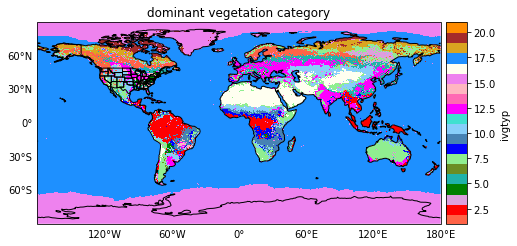

In [29]:
ivgtyp.plot.polygons(backend='matplotlib', pixel_ratio = 4.0, features=["states", "coastline"],
         width=600, height=500, cmap=colors,clim=(1, 21),
         periodic_elements="split", title=ivgtyp.long_name) 

:Image   [x,y]   (x_y ivgtyp)
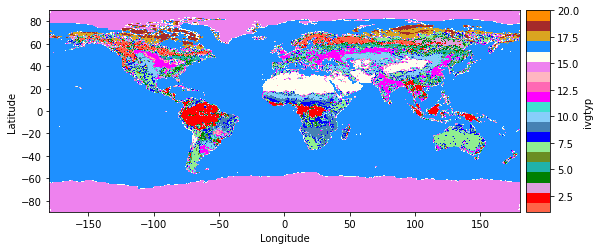

In [7]:
ivgtyp.plot.polygons(
    colorbar=True,
    cmap=colors,
    clim=(1, 20)
)